Chuỗi từ 2010-02-05 00:00:00 đến 2012-10-26 00:00:00, tổng 143 tuần
count    1.430000e+02
mean     4.711342e+07
std      5.444206e+06
min      3.959985e+07
25%      4.488059e+07
50%      4.624390e+07
75%      4.779202e+07
max      8.093142e+07
Name: total_sales, dtype: float64

=== KIỂM TRA TÍNH LIÊN TỤC CHUỖI TỔNG HỢP ===
Khoảng cách giữa các tuần - unique values: <TimedeltaArray>
['7 days']
Length: 1, dtype: timedelta64[us]
Sau asfreq('W-FRI') - số NaN xuất hiện (dấu hiệu gap có thật): 0

=== KIỂM TRA GIÁ TRỊ <= 0 TRƯỚC MULTIPLICATIVE DECOMPOSITION ===
Số tuần có total_sales <= 0: 0

=== ADF TEST ===
ADF Statistic: -5.9083
p-value: 0.0000
Kết luận: STATIONARY (bác bỏ H0)

=== KPSS TEST ===
KPSS Statistic: 0.0489
p-value: 0.1000 (lưu ý: có thể là giá trị biên do interpolation nội bộ của statsmodels)
Kết luận: STATIONARY (không bác bỏ H0)

=== DIỄN GIẢI KẾT HỢP 2 TEST (đọc cả hai cùng lúc, không đọc riêng lẻ) ===
- Cả 2 đồng thuận STATIONARY     -> dùng thẳng, không cần differencing
- 

C:\Users\HP\AppData\Local\Temp\ipykernel_13828\2656547732.py:67: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')


=== Đã lưu decomposition_total_sales_additive.png ===
=== Đã lưu decomposition_total_sales_multiplicative.png ===
=== Đã lưu total_weekly_sales.csv ===


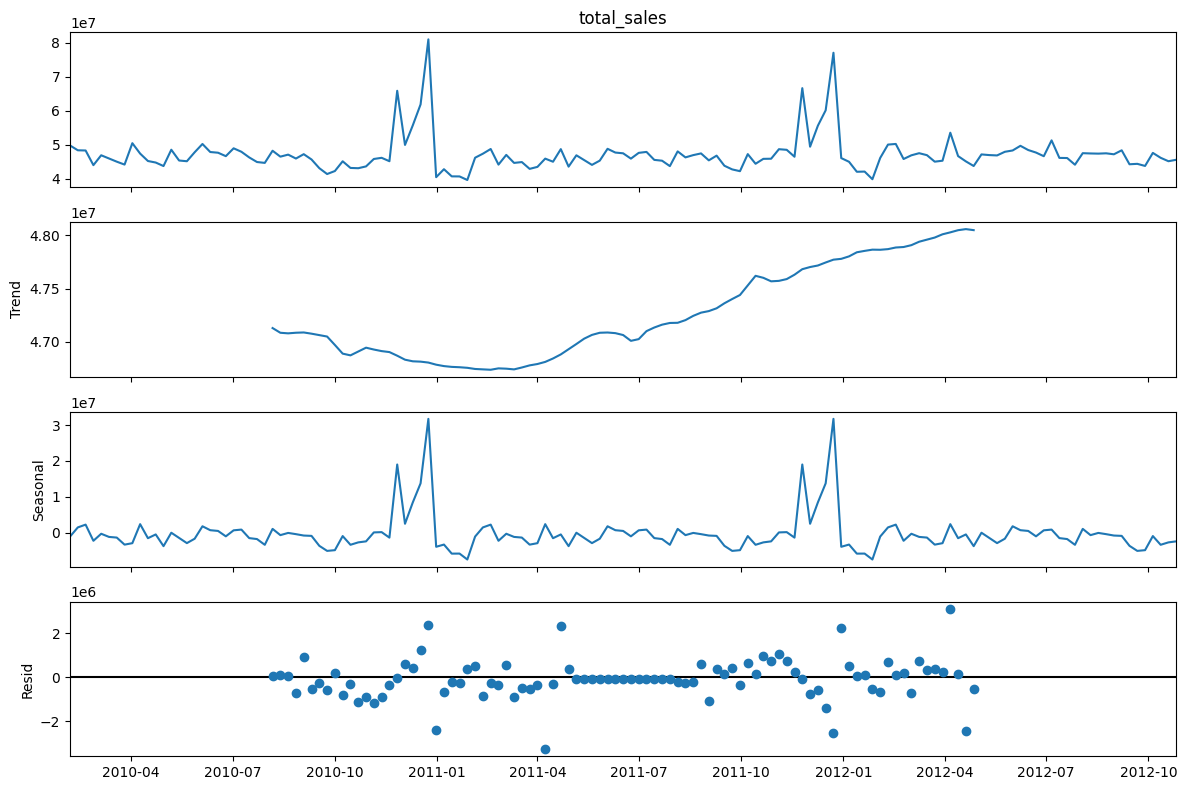

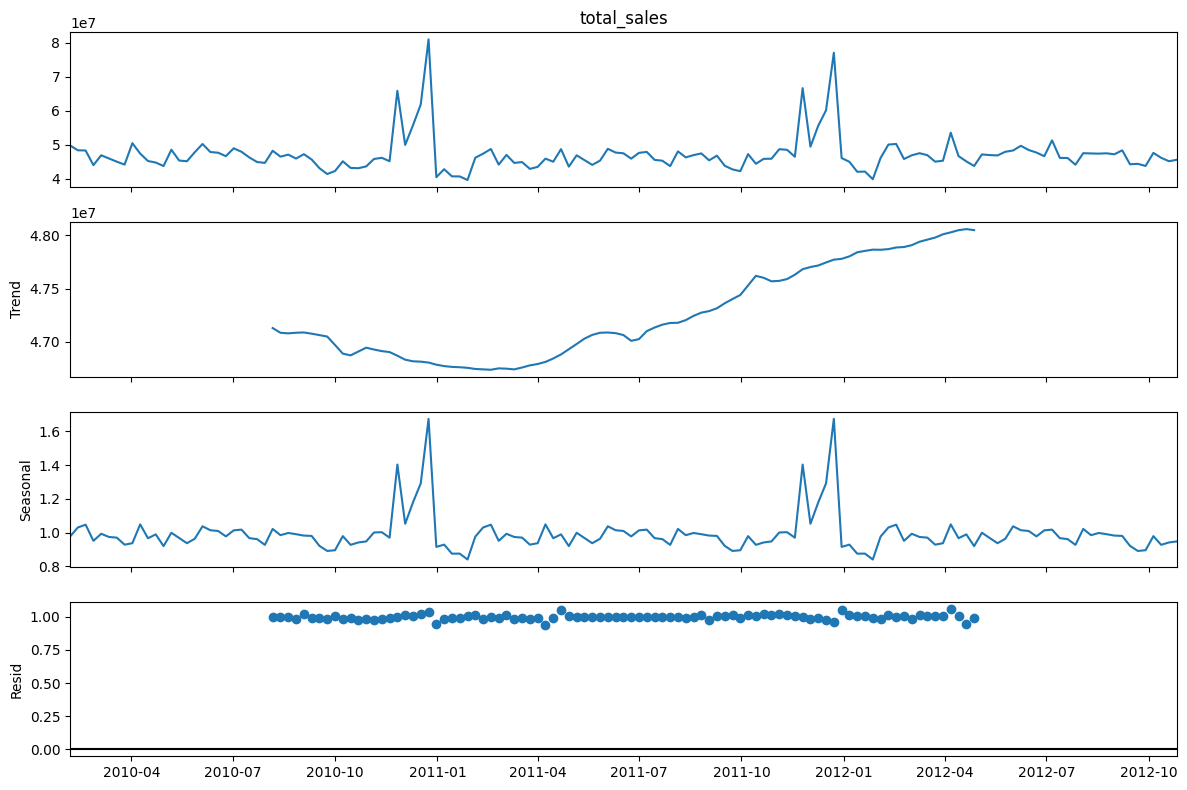

In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

BASE = "C:/Users/HP/Downloads/DS/da9/walmart-demand-forecast"
PROCESSED = f"{BASE}/data/processed"
REPORTS = f"{BASE}/reports"
os.makedirs(REPORTS, exist_ok=True)

con = duckdb.connect()

# --- Tổng hợp Weekly_Sales toàn công ty theo tuần ---
total_weekly = con.execute(f"""
    SELECT Date, SUM(Weekly_Sales) AS total_sales
    FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
    GROUP BY Date
    ORDER BY Date
""").df()

total_weekly['Date'] = pd.to_datetime(total_weekly['Date'])
ts = total_weekly.set_index('Date')['total_sales']

print(f"Chuỗi từ {ts.index.min()} đến {ts.index.max()}, tổng {len(ts)} tuần")
print(ts.describe())

# =========================================================
# KIỂM TRA 1: tính liên tục của chuỗi (gap check) trước khi decomposition
# =========================================================
date_diffs = ts.index.to_series().diff().dropna()
print(f"\n=== KIỂM TRA TÍNH LIÊN TỤC CHUỖI TỔNG HỢP ===")
print(f"Khoảng cách giữa các tuần - unique values: {date_diffs.unique()}")
# Kỳ vọng: chỉ 1 giá trị duy nhất là 7 ngày. Nếu có giá trị khác -> có gap thật, cần xử lý.

ts = ts.asfreq('W-FRI')  # Walmart mốc theo thứ Sáu hàng tuần theo tài liệu gốc
n_na_after_asfreq = ts.isna().sum()
print(f"Sau asfreq('W-FRI') - số NaN xuất hiện (dấu hiệu gap có thật): {n_na_after_asfreq}")
if n_na_after_asfreq > 0:
    print("CẢNH BÁO: có gap thật trong chuỗi tổng hợp. Các tuần bị thiếu:")
    print(ts[ts.isna()])
    print("-> Cần quyết định interpolate hay giữ nguyên NaN và note rõ trong README trước khi chạy ADF/KPSS/decomposition.")

# =========================================================
# KIỂM TRA 2: giá trị <= 0 trước khi cân nhắc multiplicative decomposition
# =========================================================
n_nonpositive_weeks = (ts <= 0).sum()
print(f"\n=== KIỂM TRA GIÁ TRỊ <= 0 TRƯỚC MULTIPLICATIVE DECOMPOSITION ===")
print(f"Số tuần có total_sales <= 0: {n_nonpositive_weeks}")
if n_nonpositive_weeks > 0:
    print("CẢNH BÁO: multiplicative decomposition sẽ cho NaN/inf tại các tuần này.")
    print(ts[ts <= 0])

# =========================================================
# ADF TEST: H0 = có unit root (non-stationary)
# =========================================================
adf_result = adfuller(ts.dropna(), autolag='AIC')
print("\n=== ADF TEST ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print(f"Kết luận: {'STATIONARY (bác bỏ H0)' if adf_result[1] < 0.05 else 'NON-STATIONARY (không bác bỏ H0)'}")

# =========================================================
# KPSS TEST: H0 = stationary (đối chiếu với ADF)
# =========================================================
kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')
print("\n=== KPSS TEST ===")
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"p-value: {kpss_result[1]:.4f} (lưu ý: có thể là giá trị biên do interpolation nội bộ của statsmodels)")
print(f"Kết luận: {'STATIONARY (không bác bỏ H0)' if kpss_result[1] > 0.05 else 'NON-STATIONARY (bác bỏ H0)'}")

print("""
=== DIỄN GIẢI KẾT HỢP 2 TEST (đọc cả hai cùng lúc, không đọc riêng lẻ) ===
- Cả 2 đồng thuận STATIONARY     -> dùng thẳng, không cần differencing
- Cả 2 đồng thuận NON-STATIONARY -> cần differencing (d=1) trước SARIMA
- ADF: stationary, KPSS: non-stationary -> trend-stationary, cần detrend
- ADF: non-stationary, KPSS: stationary -> difference-stationary, cần diff
""")

# =========================================================
# SEASONAL DECOMPOSITION: chạy cả additive và multiplicative để so sánh
# =========================================================
models_to_run = ['additive']
if n_nonpositive_weeks == 0:
    models_to_run.append('multiplicative')
else:
    print("\n=== BỎ QUA multiplicative decomposition vì có giá trị <= 0 (xem cảnh báo ở trên) ===")

for model_type in models_to_run:
    decomposition = seasonal_decompose(ts.dropna(), model=model_type, period=52)
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.tight_layout()
    fig.savefig(f"{REPORTS}/decomposition_total_sales_{model_type}.png", dpi=100)
    
    print(f"=== Đã lưu decomposition_total_sales_{model_type}.png ===")


total_weekly.to_csv(f"{PROCESSED}/total_weekly_sales.csv", index=False)
print("=== Đã lưu total_weekly_sales.csv ===")

In [2]:
import pandas as pd

# Các ngày lễ đặc biệt trong dataset Walmart (theo tài liệu gốc competition)
special_holidays = {
    'Super_Bowl': ['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'],
    'Labor_Day': ['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'],
    'Thanksgiving': ['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'],
    'Christmas': ['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'],
}

total_weekly = pd.read_csv(f"{PROCESSED}/total_weekly_sales.csv", parse_dates=['Date'])

for holiday_name, dates in special_holidays.items():
    holiday_dates = pd.to_datetime(dates)
    total_weekly[f'is_{holiday_name}'] = total_weekly['Date'].isin(holiday_dates).astype(int)

print(total_weekly[total_weekly[[c for c in total_weekly.columns if c.startswith('is_')]].sum(axis=1) > 0])

# So sánh trung bình sales các tuần lễ vs tuần thường - định lượng rõ mức độ ảnh hưởng
baseline_mean = total_weekly.loc[
    total_weekly[[c for c in total_weekly.columns if c.startswith('is_')]].sum(axis=1) == 0,
    'total_sales'
].mean()

print(f"\nTrung bình sales tuần THƯỜNG: {baseline_mean:,.0f}")
for holiday_name in special_holidays:
    col = f'is_{holiday_name}'
    if total_weekly[col].sum() > 0:
        holiday_mean = total_weekly.loc[total_weekly[col] == 1, 'total_sales'].mean()
        pct_lift = (holiday_mean / baseline_mean - 1) * 100
        print(f"{holiday_name}: trung bình {holiday_mean:,.0f} ({pct_lift:+.1f}% so với tuần thường)")

total_weekly.to_csv(f"{PROCESSED}/total_weekly_sales_with_holidays.csv", index=False)
print("\n=== Đã lưu total_weekly_sales_with_holidays.csv ===")

          Date  total_sales  is_Super_Bowl  is_Labor_Day  is_Thanksgiving  \
1   2010-02-12  48336677.63              1             0                0   
31  2010-09-10  45634397.84              0             1                0   
42  2010-11-26  65821003.24              0             0                1   
47  2010-12-31  40432519.00              0             0                0   
53  2011-02-11  47336192.79              1             0                0   
83  2011-09-09  46763227.53              0             1                0   
94  2011-11-25  66593605.26              0             0                1   
99  2011-12-30  46042461.04              0             0                0   
105 2012-02-10  50009407.92              1             0                0   
135 2012-09-07  48330059.31              0             1                0   

     is_Christmas  
1               0  
31              0  
42              0  
47              1  
53              0  
83              0  
94          

In [3]:
import pandas as pd

total_weekly = pd.read_csv(f"{PROCESSED}/total_weekly_sales_with_holidays.csv", parse_dates=['Date'])
total_weekly = total_weekly.sort_values('Date').reset_index(drop=True)

# Xem 3 tuần trước và sau mỗi ngày Christmas đã gán, để tìm tuần đỉnh thật
christmas_dates = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28'])

for cd in christmas_dates:
    idx = total_weekly[total_weekly['Date'] == cd].index
    if len(idx) > 0:
        i = idx[0]
        window = total_weekly.iloc[max(0, i-3):i+2][['Date', 'total_sales']]
        print(f"\n=== Xung quanh mốc Christmas gán = {cd.date()} ===")
        print(window.to_string(index=False))


=== Xung quanh mốc Christmas gán = 2010-12-31 ===
      Date  total_sales
2010-12-10  55666770.39
2010-12-17  61820799.85
2010-12-24  80931415.60
2010-12-31  40432519.00
2011-01-07  42775787.77

=== Xung quanh mốc Christmas gán = 2011-12-30 ===
      Date  total_sales
2011-12-09  55561147.70
2011-12-16  60085695.94
2011-12-23  76998241.31
2011-12-30  46042461.04
2012-01-06  44955421.95


In [4]:
#tạo feature đã hiệu chỉnh
import pandas as pd

total_weekly = pd.read_csv(f"{PROCESSED}/total_weekly_sales_with_holidays.csv", parse_dates=['Date'])
total_weekly = total_weekly.sort_values('Date').reset_index(drop=True)

# Tuần chứa 24/12 mỗi năm - đây mới là tuần cao điểm thật của Christmas
true_christmas_peak_dates = pd.to_datetime(['2010-12-24', '2011-12-23', '2012-12-21', '2013-12-20'])
total_weekly['is_Christmas_true_peak'] = total_weekly['Date'].isin(true_christmas_peak_dates).astype(int)

# Định lượng lại đúng mức độ ảnh hưởng sau khi sửa
mask_flags = [c for c in total_weekly.columns if c.startswith('is_') and c != 'is_Christmas_true_peak']
baseline_mask = (total_weekly[mask_flags].sum(axis=1) == 0) & (total_weekly['is_Christmas_true_peak'] == 0)
baseline_mean = total_weekly.loc[baseline_mask, 'total_sales'].mean()

peak_mean = total_weekly.loc[total_weekly['is_Christmas_true_peak'] == 1, 'total_sales'].mean()
pct_lift = (peak_mean / baseline_mean - 1) * 100
print(f"Trung bình sales tuần THƯỜNG (đã loại toàn bộ tuần lễ): {baseline_mean:,.0f}")
print(f"Christmas_true_peak (tuần chứa 24/12): {peak_mean:,.0f} ({pct_lift:+.1f}% so với tuần thường)")

# So sánh lại: Christmas_true_peak có thật sự là lễ mạnh nhất năm không, so với Thanksgiving
thanksgiving_mean = total_weekly.loc[total_weekly['is_Thanksgiving'] == 1, 'total_sales'].mean()
print(f"Thanksgiving: {thanksgiving_mean:,.0f} ({(thanksgiving_mean/baseline_mean-1)*100:+.1f}%)")

total_weekly.to_csv(f"{PROCESSED}/total_weekly_sales_final.csv", index=False)
print("\n=== Đã lưu total_weekly_sales_final.csv (bản đầy đủ, dùng cho modeling) ===")

Trung bình sales tuần THƯỜNG (đã loại toàn bộ tuần lễ): 46,366,334
Christmas_true_peak (tuần chứa 24/12): 78,964,828 (+70.3% so với tuần thường)
Thanksgiving: 66,207,304 (+42.8%)

=== Đã lưu total_weekly_sales_final.csv (bản đầy đủ, dùng cho modeling) ===


In [5]:
#Seasonal unit root test 
import pandas as pd
from pmdarima.arima import nsdiffs
from pmdarima.arima import CHTest
from pmdarima.arima import OCSBTest

BASE = "C:/Users/HP/Downloads/DS/da9/walmart-demand-forecast"
PROCESSED = f"{BASE}/data/processed"

total_weekly = pd.read_csv(f"{PROCESSED}/total_weekly_sales_final.csv", parse_dates=['Date'])
total_weekly = total_weekly.sort_values('Date').reset_index(drop=True)
ts = total_weekly.set_index('Date')['total_sales'].asfreq('W-FRI')

# --- Canova-Hansen test: H0 = không cần seasonal differencing ---
ch_test = CHTest(m=52)
D_ch = ch_test.estimate_seasonal_differencing_term(ts.values)
print(f"=== CANOVA-HANSEN TEST (m=52) ===")
print(f"Seasonal differencing đề xuất (D): {D_ch}")

# --- OCSB test: cách tiếp cận khác, đối chiếu với Canova-Hansen ---
ocsb_test = OCSBTest(m=52)
D_ocsb = ocsb_test.estimate_seasonal_differencing_term(ts.values)
print(f"\n=== OCSB TEST (m=52) ===")
print(f"Seasonal differencing đề xuất (D): {D_ocsb}")

# --- nsdiffs: wrapper tổng hợp, cho phép chọn test method ---
D_auto_ch = nsdiffs(ts.values, m=52, max_D=2, test='ch')
D_auto_ocsb = nsdiffs(ts.values, m=52, max_D=2, test='ocsb')
print(f"\n=== TỔNG HỢP nsdiffs ===")
print(f"D theo Canova-Hansen: {D_auto_ch}")
print(f"D theo OCSB: {D_auto_ocsb}")

print("""
=== DIỄN GIẢI ===
- Nếu cả 2 test đồng thuận D=0 -> không cần seasonal differencing, seasonal component ổn định
  (khớp với decomposition additive đã thấy biên độ seasonal không đổi theo thời gian)
- Nếu D>=1 -> cần seasonal differencing trước khi fit SARIMAX
- Lưu ý: chuỗi chỉ có 143 tuần (~2.75 chu kỳ mùa vụ với m=52) -> seasonal unit root test
  có power thấp với chuỗi ngắn thế này, kết quả cần diễn giải thận trọng, không tuyệt đối hoá
""")

=== CANOVA-HANSEN TEST (m=52) ===
Seasonal differencing đề xuất (D): 1

=== OCSB TEST (m=52) ===
Seasonal differencing đề xuất (D): 0

=== TỔNG HỢP nsdiffs ===
D theo Canova-Hansen: 1
D theo OCSB: 0

=== DIỄN GIẢI ===
- Nếu cả 2 test đồng thuận D=0 -> không cần seasonal differencing, seasonal component ổn định
  (khớp với decomposition additive đã thấy biên độ seasonal không đổi theo thời gian)
- Nếu D>=1 -> cần seasonal differencing trước khi fit SARIMAX
- Lưu ý: chuỗi chỉ có 143 tuần (~2.75 chu kỳ mùa vụ với m=52) -> seasonal unit root test
  có power thấp với chuỗi ngắn thế này, kết quả cần diễn giải thận trọng, không tuyệt đối hoá



In [6]:
#auto_arima
import pmdarima as pm
import numpy as np

# Thử cả D=0 và D=1, so sánh AICc - nhưng AICc chỉ là bước sàng lọc sơ bộ,
# quyết định cuối cùng sẽ dựa vào rolling backtest ở bước sau, không dừng ở đây
for D_candidate in [0, 1]:
    print(f"\n=== Thử nghiệm với D={D_candidate} ===")
    model = pm.auto_arima(
        ts.dropna(),
        seasonal=True,
        m=52,
        D=D_candidate,
        max_p=3, max_q=3, max_P=2, max_Q=2,
        trace=True,
        error_action='ignore',
        suppress_warnings=True,
        stepwise=True
    )
    print(f"Order tốt nhất: {model.order}, Seasonal order: {model.seasonal_order}")
    print(f"AICc: {model.aicc():.2f}")


=== Thử nghiệm với D=0 ===
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=4769.760, Time=16.48 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=4844.691, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=4804.381, Time=2.11 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=4797.927, Time=1.78 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=5462.768, Time=0.02 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=inf, Time=7.32 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=4767.813, Time=7.90 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=4830.548, Time=0.47 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=4769.801, Time=52.93 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=4773.262, Time=63.08 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=4777.852, Time=5.33 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=4779.475, Time=8.19 sec
 ARIMA(3,0,2)(1,0,0)[52] intercept   : AIC=4769.157, Time=13.03 sec
 ARIMA(2,0,3)(1,0,0)[52] intercept   : AIC=4779.845, Time=7

In [7]:
#Đánh giá
import pmdarima as pm
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

ts_clean = ts.dropna()
n = len(ts_clean)

# Rolling-origin backtest: train tăng dần, luôn test đúng 4 tuần tiếp theo
# (không random split - đây là time series, thứ tự thời gian phải giữ nguyên)
test_horizon = 4
n_folds = 6  # số lần backtest, lùi dần từ cuối chuỗi

results = {'D=0': [], 'D=1': [], 'seasonal_naive': []}

for fold in range(n_folds):
    train_end = n - test_horizon * (n_folds - fold)
    train = ts_clean.iloc[:train_end]
    test = ts_clean.iloc[train_end:train_end + test_horizon]

    if len(test) < test_horizon or len(train) < 104:
        continue

    # --- Model D=0 (order đã tìm được ở bước trước) ---
    model_d0 = pm.ARIMA(order=(2,0,2), seasonal_order=(1,0,0,52), with_intercept=True)
    model_d0.fit(train)
    pred_d0 = model_d0.predict(n_periods=test_horizon)

    # --- Model D=1 ---
    model_d1 = pm.ARIMA(order=(0,1,1), seasonal_order=(0,1,2,52))
    model_d1.fit(train)
    pred_d1 = model_d1.predict(n_periods=test_horizon)

    # --- Seasonal naive baseline: dự báo = giá trị đúng 52 tuần trước ---
    pred_naive = train.iloc[-52:-52+test_horizon].values if len(train) >= 52 else [train.mean()]*test_horizon

    mape_d0 = mean_absolute_percentage_error(test, pred_d0) * 100
    mape_d1 = mean_absolute_percentage_error(test, pred_d1) * 100
    mape_naive = mean_absolute_percentage_error(test, pred_naive) * 100

    results['D=0'].append(mape_d0)
    results['D=1'].append(mape_d1)
    results['seasonal_naive'].append(mape_naive)

    print(f"Fold {fold+1}: D=0 MAPE={mape_d0:.2f}%, D=1 MAPE={mape_d1:.2f}%, naive MAPE={mape_naive:.2f}%")

print("\n=== TRUNG BÌNH MAPE QUA CÁC FOLD ===")
for k, v in results.items():
    if v:
        print(f"{k}: {np.mean(v):.2f}% (std: {np.std(v):.2f})")

C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal AR

Fold 1: D=0 MAPE=2.74%, D=1 MAPE=2.36%, naive MAPE=4.09%


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal AR

Fold 2: D=0 MAPE=2.49%, D=1 MAPE=2.95%, naive MAPE=3.62%


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal AR

...

Fold 4: D=0 MAPE=1.62%, D=1 MAPE=2.22%, naive MAPE=1.80%


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal AR

Fold 5: D=0 MAPE=1.04%, D=1 MAPE=1.70%, naive MAPE=2.86%


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal AR

Fold 6: D=0 MAPE=1.83%, D=1 MAPE=2.14%, naive MAPE=1.69%

=== TRUNG BÌNH MAPE QUA CÁC FOLD ===
D=0: 1.88% (std: 0.57)
D=1: 3.03% (std: 1.73)
seasonal_naive: 2.55% (std: 1.05)


=== KIỂM TRA TRƯỚC KHI FIT ===
Số quan sát: 143
NaN trong ts: 0
NaN trong exog:
is_Super_Bowl             0
is_Labor_Day              0
is_Thanksgiving           0
is_Christmas_true_peak    0
dtype: int64
Exog columns: ['is_Super_Bowl', 'is_Labor_Day', 'is_Thanksgiving', 'is_Christmas_true_peak']

Train: 135 tuần (2010-02-05 00:00:00 -> 2012-08-31 00:00:00)
Test:  8 tuần (2012-09-07 00:00:00 -> 2012-10-26 00:00:00)


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'



=== MODEL SUMMARY ===
                                      SARIMAX Results                                      
Dep. Variable:                         total_sales   No. Observations:                  135
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 52)   Log Likelihood               -2263.269
Date:                             Sun, 05 Jul 2026   AIC                           4538.537
Time:                                     19:07:06   BIC                           4555.969
Sample:                                 02-05-2010   HQIC                          4545.621
                                      - 08-31-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1068      1.021      0.105      0.917      -1.895       2.108
ar.L

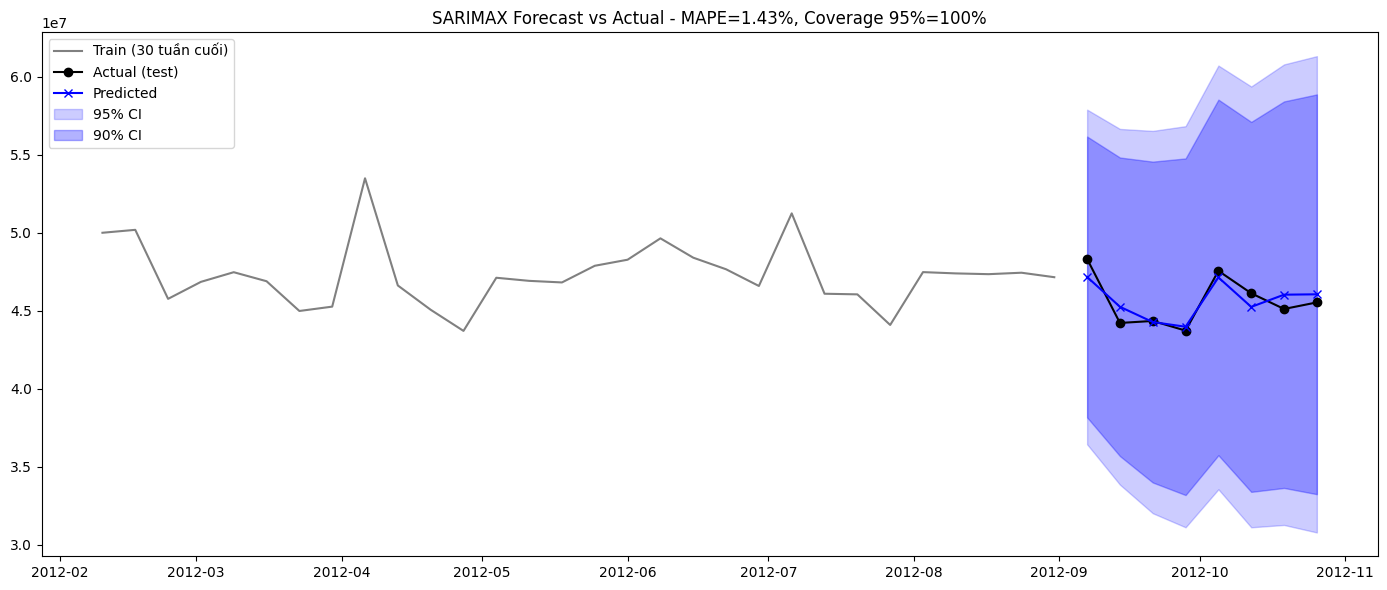

In [10]:
#SARIMAX + prediction interval
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error

BASE = "C:/Users/HP/Downloads/DS/da9/walmart-demand-forecast"
PROCESSED = f"{BASE}/data/processed"
REPORTS = f"{BASE}/reports"

# 1. Load data đã có đầy đủ exogenous variables
# ============================================================
df = pd.read_csv(f"{PROCESSED}/total_weekly_sales_final.csv", parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.set_index('Date').asfreq('W-FRI')

ts = df['total_sales']

exog_cols = ['is_Super_Bowl', 'is_Labor_Day', 'is_Thanksgiving', 'is_Christmas_true_peak']
exog = df[exog_cols]

print("=== KIỂM TRA TRƯỚC KHI FIT ===")
print(f"Số quan sát: {len(ts)}")
print(f"NaN trong ts: {ts.isna().sum()}")
print(f"NaN trong exog:\n{exog.isna().sum()}")
print(f"Exog columns: {list(exog.columns)}")


# 2. Train/test split - giữ 8 tuần cuối để test thật (out-of-sample)

# ============================================================
test_horizon = 8
train_ts, test_ts = ts.iloc[:-test_horizon], ts.iloc[-test_horizon:]
train_exog, test_exog = exog.iloc[:-test_horizon], exog.iloc[-test_horizon:]

print(f"\nTrain: {len(train_ts)} tuần ({train_ts.index.min()} -> {train_ts.index.max()})")
print(f"Test:  {len(test_ts)} tuần ({test_ts.index.min()} -> {test_ts.index.max()})")


# 3. Fit SARIMAX với order đã chốt qua backtest: (2,0,2)(1,0,0,52)
# ============================================================
model = SARIMAX(
    train_ts,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 0, 52), 
)
fitted = model.fit(disp=False)

print("\n=== MODEL SUMMARY ===")
print(fitted.summary())


# 4. Kiểm định giả định residual - BẮT BUỘC, không được bỏ qua

# ============================================================
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as scipy_stats

residuals = fitted.resid

# Ljung-Box test: H0 = residual không có autocorrelation (residual là white noise)
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 52], return_df=True)
print("\n=== LJUNG-BOX TEST (H0: residual là white noise) ===")
print(lb_test)
print("Diễn giải: p-value > 0.05 -> residual KHÔNG còn autocorrelation, model đã bắt hết pattern")
print("           p-value < 0.05 -> residual còn pattern, model CHƯA bắt hết, cần xem lại order")

# Kiểm tra normality của residual (ảnh hưởng đến độ tin cậy của prediction interval)
shapiro_stat, shapiro_p = scipy_stats.shapiro(residuals)
print(f"\n=== SHAPIRO-WILK TEST (H0: residual normal distributed) ===")
print(f"Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
print("Diễn giải: p-value < 0.05 -> residual KHÔNG normal -> prediction interval dựa trên")
print("           phân phối chuẩn có thể không chính xác, cần thận trọng khi diễn giải CI")


# 5. Forecast với prediction interval trên tập test thật
# ============================================================
forecast_result = fitted.get_forecast(steps=test_horizon, exog=test_exog)
pred_mean = forecast_result.predicted_mean
conf_int_90 = forecast_result.conf_int(alpha=0.10)  # 90% CI
conf_int_95 = forecast_result.conf_int(alpha=0.05)  # 95% CI

comparison = pd.DataFrame({
    'actual': test_ts,
    'predicted': pred_mean,
    'lower_95': conf_int_95.iloc[:, 0],
    'upper_95': conf_int_95.iloc[:, 1],
    'lower_90': conf_int_90.iloc[:, 0],
    'upper_90': conf_int_90.iloc[:, 1],
})
comparison['within_95_CI'] = (comparison['actual'] >= comparison['lower_95']) & \
                               (comparison['actual'] <= comparison['upper_95'])

print("\n=== SO SÁNH DỰ BÁO VS THỰC TẾ (8 tuần test) ===")
print(comparison.to_string())

mape = mean_absolute_percentage_error(test_ts, pred_mean) * 100
coverage_95 = comparison['within_95_CI'].mean() * 100
print(f"\nMAPE trên test set: {mape:.2f}%")
print(f"Coverage thực tế của 95% CI: {coverage_95:.1f}% (kỳ vọng lý thuyết: 95%)")
print("Diễn giải: nếu coverage thực tế lệch xa 95% (VD chỉ 60-70%), nghĩa là")
print("           prediction interval bị UNDERESTIMATE độ bất định - rủi ro nghiêm trọng")
print("           vì báo cáo sai mức độ tự tin cho business")


# 6. So sánh với seasonal naive - bắt buộc theo chuẩn đã đặt ra
# ============================================================
naive_pred = ts.iloc[-test_horizon-52:-52].values
mape_naive = mean_absolute_percentage_error(test_ts, naive_pred) * 100
print(f"\nMAPE seasonal naive (cùng kỳ năm trước): {mape_naive:.2f}%")
print(f"SARIMAX {'THẮNG' if mape < mape_naive else 'THUA'} naive baseline")


# 7. Visualize
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_ts.index[-30:], train_ts.iloc[-30:], label='Train (30 tuần cuối)', color='gray')
ax.plot(test_ts.index, test_ts, label='Actual (test)', color='black', marker='o')
ax.plot(pred_mean.index, pred_mean, label='Predicted', color='blue', marker='x')
ax.fill_between(pred_mean.index, conf_int_95.iloc[:, 0], conf_int_95.iloc[:, 1],
                 alpha=0.2, color='blue', label='95% CI')
ax.fill_between(pred_mean.index, conf_int_90.iloc[:, 0], conf_int_90.iloc[:, 1],
                 alpha=0.3, color='blue', label='90% CI')
ax.legend()
ax.set_title(f'SARIMAX Forecast vs Actual - MAPE={mape:.2f}%, Coverage 95%={coverage_95:.0f}%')
plt.tight_layout()
plt.savefig(f"{REPORTS}/sarimax_forecast_vs_actual.png", dpi=100)
print(f"\n=== Đã lưu sarimax_forecast_vs_actual.png ===")

comparison.to_csv(f"{PROCESSED}/sarimax_test_comparison.csv")
print("=== Đã lưu sarimax_test_comparison.csv ===")

Train: 135 tuần, Test: 8 tuần

=== MODEL SUMMARY  ===
                                      SARIMAX Results                                      
Dep. Variable:                         total_sales   No. Observations:                  135
Model:             SARIMAX(2, 0, 2)x(1, 0, [], 52)   Log Likelihood               -1336.114
Date:                             Sun, 05 Jul 2026   AIC                           2684.227
Time:                                     19:39:33   BIC                           2698.594
Sample:                                 02-05-2010   HQIC                          2689.992
                                      - 08-31-2012                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1218      0.442      0.276      0.7

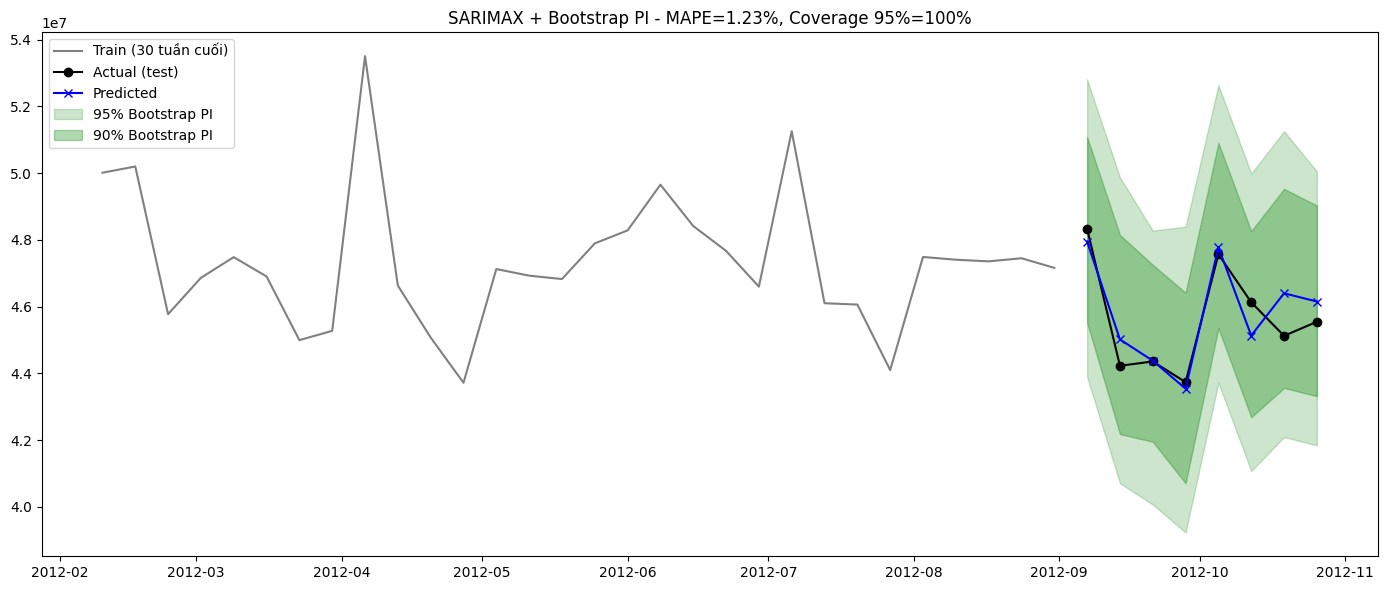

In [15]:
#Bootstrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as scipy_stats
from sklearn.metrics import mean_absolute_percentage_error

BASE = "C:/Users/HP/Downloads/DS/da9/walmart-demand-forecast"
PROCESSED = f"{BASE}/data/processed"
REPORTS = f"{BASE}/reports"


# 1. Load data - CHỈ dùng ts, KHÔNG dùng exog holiday dummies

df = pd.read_csv(f"{PROCESSED}/total_weekly_sales_final.csv", parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df = df.set_index('Date').asfreq('W-FRI')
ts = df['total_sales']

test_horizon = 8
train_ts, test_ts = ts.iloc[:-test_horizon], ts.iloc[-test_horizon:]

print(f"Train: {len(train_ts)} tuần, Test: {len(test_ts)} tuần")

# ============================================================
# 2. Fit SARIMAX - Cách B: order (2,0,2)(1,0,0,52), không exog

model = SARIMAX(
    train_ts,
    order=(2, 0, 2),
    seasonal_order=(1, 0, 0, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fitted = model.fit(disp=False)
print("\n=== MODEL SUMMARY  ===")
print(fitted.summary())

residuals = fitted.resid[55:] 

# Kiểm tra lại residual diagnostics
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 52], return_df=True)
print("\n=== LJUNG-BOX TEST ===")
print(lb_test)

shapiro_stat, shapiro_p = scipy_stats.shapiro(residuals)
print(f"\n=== SHAPIRO-WILK ===")
print(f"Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
print(f"Kurtosis thực tế: {scipy_stats.kurtosis(residuals):.2f} (normal=0, càng cao càng fat-tailed)")
print("-> Residual KHÔNG normal, xác nhận cần dùng bootstrap PI thay vì CI parametric")

# ============================================================
# 3. Point forecast trung tâm (không đổi, dùng nguyên )

point_forecast = fitted.get_forecast(steps=test_horizon).predicted_mean


# 4. BOOTSTRAP PREDICTION INTERVAL
#    Resample residual thật, cộng vào forecast trung tâm, lấy percentile

n_bootstrap = 5000
np.random.seed(42)  

bootstrap_forecasts = np.zeros((n_bootstrap, test_horizon))
for b in range(n_bootstrap):
    
    sampled_residuals = np.random.choice(residuals, size=test_horizon, replace=True)
    bootstrap_forecasts[b, :] = point_forecast.values + sampled_residuals

# Percentile trực tiếp từ phân phối thực nghiệm - không giả định normal
lower_95_boot = np.percentile(bootstrap_forecasts, 2.5, axis=0)
upper_95_boot = np.percentile(bootstrap_forecasts, 97.5, axis=0)
lower_90_boot = np.percentile(bootstrap_forecasts, 5, axis=0)
upper_90_boot = np.percentile(bootstrap_forecasts, 95, axis=0)

comparison = pd.DataFrame({
    'actual': test_ts.values,
    'predicted': point_forecast.values,
    'lower_95_bootstrap': lower_95_boot,
    'upper_95_bootstrap': upper_95_boot,
    'lower_90_bootstrap': lower_90_boot,
    'upper_90_bootstrap': upper_90_boot,
}, index=test_ts.index)

comparison['within_95_CI'] = (comparison['actual'] >= comparison['lower_95_bootstrap']) & \
                               (comparison['actual'] <= comparison['upper_95_bootstrap'])

print("\n=== SO SÁNH DỰ BÁO VS THỰC TẾ (Bootstrap PI, buffer=55) ===")
print(comparison.to_string())

mape = mean_absolute_percentage_error(test_ts, point_forecast) * 100
coverage_95 = comparison['within_95_CI'].mean() * 100
avg_ci_width_pct = ((comparison['upper_95_bootstrap'] - comparison['lower_95_bootstrap']) / comparison['predicted']).mean() * 100

print(f"\nMAPE: {mape:.2f}%")
print(f"Coverage 95% CI (bootstrap): {coverage_95:.1f}%")
print(f"Độ rộng CI trung bình: {avg_ci_width_pct:.1f}% so với giá trị dự báo trung tâm")

naive_pred = ts.iloc[-test_horizon-52:-52].values
mape_naive = mean_absolute_percentage_error(test_ts, naive_pred) * 100
print(f"MAPE seasonal naive: {mape_naive:.2f}% -> SARIMAX {'THẮNG' if mape < mape_naive else 'THUA'}")


# 5. Visualize
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train_ts.index[-30:], train_ts.iloc[-30:], label='Train (30 tuần cuối)', color='gray')
ax.plot(test_ts.index, test_ts, label='Actual (test)', color='black', marker='o')
ax.plot(comparison.index, comparison['predicted'], label='Predicted', color='blue', marker='x')
ax.fill_between(comparison.index, comparison['lower_95_bootstrap'], comparison['upper_95_bootstrap'],
                 alpha=0.2, color='green', label='95% Bootstrap PI')
ax.fill_between(comparison.index, comparison['lower_90_bootstrap'], comparison['upper_90_bootstrap'],
                 alpha=0.3, color='green', label='90% Bootstrap PI')
ax.legend()
ax.set_title(f'SARIMAX + Bootstrap PI - MAPE={mape:.2f}%, Coverage 95%={coverage_95:.0f}%')
plt.tight_layout()
plt.savefig(f"{REPORTS}/sarimax_bootstrap_forecast.png", dpi=100)
print(f"\n=== Đã lưu sarimax_bootstrap_forecast.png ===")

comparison.to_csv(f"{PROCESSED}/sarimax_bootstrap_comparison.csv")
print("=== Đã lưu sarimax_bootstrap_comparison.csv ===")


# 6. Business insight tổng kết - dịch sang ngôn ngữ business
# ============================================================
avg_weekly_sales = ts.mean()
print(f"""
=== TÓM TẮT INSIGHT KINH DOANH ===
Doanh số trung bình mỗi tuần: {avg_weekly_sales:,.0f} USD
Sai số dự báo trung bình (MAPE): {mape:.2f}% -> tương đương ~{avg_weekly_sales*mape/100:,.0f} USD/tuần
Độ rộng khoảng tin cậy 95%: ~{avg_ci_width_pct:.0f}% giá trị dự báo trung tâm
-> Nếu Inventory Planner dùng cận trên của Bootstrap PI làm mức nhập hàng an toàn,
   xác suất thiếu hàng trong tuần đó về lý thuyết dưới 2.5%, dựa trên hình dạng
   thực nghiệm của sai số quá khứ (không giả định phân phối chuẩn).
""")

In [16]:
#Kiểm chứng SARIMAX cho vài Store-Dept cụ thể
import duckdb
import pandas as pd

PROCESSED = f"{BASE}/data/processed"
con = duckdb.connect()

# Lấy thông tin để chọn 3 cặp đại diện
candidates = con.execute(f"""
    WITH weeks_per_pair AS (
        SELECT
            Store, Dept, Store_Type,
            COUNT(DISTINCT Date) AS n_weeks,
            AVG(Weekly_Sales) AS avg_sales,
            SUM(CASE WHEN MarkDown1 IS NOT NULL THEN 1 ELSE 0 END) AS n_markdown_weeks
        FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
        GROUP BY Store, Dept, Store_Type
    )
    SELECT * FROM weeks_per_pair
    WHERE n_weeks >= 104
    ORDER BY avg_sales DESC
    LIMIT 5
""").df()
print("=== Top 5 cặp Store-Dept ổn định, doanh số cao nhất (ứng viên case 1) ===")
print(candidates)

candidates_type_c = con.execute(f"""
    SELECT Store, Dept, Store_Type, COUNT(DISTINCT Date) AS n_weeks, AVG(Weekly_Sales) AS avg_sales
    FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
    WHERE Store_Type = 'C'
    GROUP BY Store, Dept, Store_Type
    HAVING n_weeks >= 104
    ORDER BY avg_sales DESC
    LIMIT 5
""").df()
print("\n=== Top 5 cặp Store_Type=C, ổn định (ứng viên case 2) ===")
print(candidates_type_c)

candidates_borderline = con.execute(f"""
    SELECT Store, Dept, Store_Type, COUNT(DISTINCT Date) AS n_weeks, AVG(Weekly_Sales) AS avg_sales
    FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
    GROUP BY Store, Dept, Store_Type
    HAVING n_weeks BETWEEN 52 AND 103
    ORDER BY avg_sales DESC
    LIMIT 5
""").df()
print("\n=== Top 5 cặp trong vùng biên giới 52-103 tuần (ứng viên case 3) ===")
print(candidates_borderline)



=== Top 5 cặp Store-Dept ổn định, doanh số cao nhất (ứng viên case 1) ===
   Store  Dept Store_Type  n_weeks      avg_sales  n_markdown_weeks
0     14    92          A      143  182527.956014              51.0
1      2    92          A      143  164840.230979              51.0
2     20    92          A      143  164633.741538              51.0
3     13    92          A      143  162034.099301              51.0
4      4    92          A      143  159365.107902              51.0

=== Top 5 cặp Store_Type=C, ổn định (ứng viên case 2) ===
   Store  Dept Store_Type  n_weeks     avg_sales
0     43    92          C      143  83646.160909
1     42    92          C      143  83497.778671
2     43    95          C      143  72883.223287
3     37    38          C      143  69388.854476
4     43    90          C      143  63668.895594

=== Top 5 cặp trong vùng biên giới 52-103 tuần (ứng viên case 3) ===
   Store  Dept Store_Type  n_weeks    avg_sales
0     17    18          B       92  8111.507500

In [17]:
#Kiểm chứng với 3 cặp
import duckdb
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats as scipy_stats
from sklearn.metrics import mean_absolute_percentage_error

PROCESSED = f"{BASE}/data/processed"
con = duckdb.connect()

cases = [
    {"name": "Case1_baseline_TypeA", "store": 14, "dept": 92},
    {"name": "Case2_small_scale_TypeC", "store": 43, "dept": 92},
    {"name": "Case3_borderline_92weeks_TypeB", "store": 17, "dept": 18},
]

results_summary = []

for case in cases:
    print(f"\n{'='*70}\n=== {case['name']} (Store={case['store']}, Dept={case['dept']}) ===\n{'='*70}")

    series_df = con.execute(f"""
        SELECT Date, Weekly_Sales
        FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
        WHERE Store = {case['store']} AND Dept = {case['dept']}
        ORDER BY Date
    """).df()

    series_df['Date'] = pd.to_datetime(series_df['Date'])
    ts_case = series_df.set_index('Date')['Weekly_Sales'].asfreq('W-FRI')

    n_total = len(ts_case)
    n_missing = ts_case.isna().sum()
    print(f"Tổng số tuần: {n_total}, số tuần NaN (gap thật): {n_missing}")

    if n_missing > 0:
        print("CẢNH BÁO: có gap trong chuỗi này - cần xử lý trước khi fit (không tự động interpolate)")
        ts_case = ts_case.interpolate(method='linear')  # tạm thời, cần note rõ trong báo cáo
        print("-> Đã tạm thời linear interpolate để pipeline chạy được, PHẢI ghi rõ trong README")

    # Test horizon và buffer thích ứng theo độ dài chuỗi
    test_horizon = 8 if n_total >= 120 else 4
    train_ts, test_ts = ts_case.iloc[:-test_horizon], ts_case.iloc[-test_horizon:]

    print(f"Train: {len(train_ts)} tuần, Test: {len(test_ts)} tuần")

    if len(train_ts) < 104:
        print(f"CẢNH BÁO: train chỉ {len(train_ts)} tuần, chưa đủ 2 chu kỳ mùa vụ (104) để seasonal AR(52) ổn định đầy đủ")

    try:
        model = SARIMAX(
            train_ts, order=(2, 0, 2), seasonal_order=(1, 0, 0, 52),
            enforce_stationarity=False, enforce_invertibility=False
        )
        fitted = model.fit(disp=False)

        # Thử buffer thích ứng 
        best_buffer, best_kurt = 52, np.inf
        for buffer_try in [52, 55, 60, 65, 70]:
            if len(fitted.resid) - buffer_try < 20:
                continue
            resid_try = fitted.resid[buffer_try:]
            kurt = abs(scipy_stats.kurtosis(resid_try))
            if kurt < best_kurt:
                best_kurt, best_buffer = kurt, buffer_try

        print(f"Buffer tối ưu tìm được: {best_buffer} (kurtosis={best_kurt:.2f})")
        residuals = fitted.resid[best_buffer:]

        lb_test = acorr_ljungbox(residuals, lags=[min(10, len(residuals)//3)], return_df=True)
        shapiro_stat, shapiro_p = scipy_stats.shapiro(residuals) if len(residuals) >= 20 else (np.nan, np.nan)

        point_forecast = fitted.get_forecast(steps=test_horizon).predicted_mean
        mape = mean_absolute_percentage_error(test_ts, point_forecast) * 100

        naive_pred = ts_case.iloc[-test_horizon-52:-52].values if n_total >= test_horizon+52 else [train_ts.mean()]*test_horizon
        mape_naive = mean_absolute_percentage_error(test_ts, naive_pred) * 100

        print(f"MAPE model: {mape:.2f}%, MAPE naive: {mape_naive:.2f}%, {'THẮNG' if mape < mape_naive else 'THUA'}")
        print(f"Ljung-Box p-value: {lb_test['lb_pvalue'].values[0]:.4f}")
        print(f"Shapiro-Wilk p-value: {shapiro_p:.4f}" if not np.isnan(shapiro_p) else "Shapiro: không đủ dữ liệu")

        results_summary.append({
            'case': case['name'], 'n_train': len(train_ts), 'best_buffer': best_buffer,
            'mape': mape, 'mape_naive': mape_naive, 'beats_naive': mape < mape_naive,
            'ljungbox_p': lb_test['lb_pvalue'].values[0], 'shapiro_p': shapiro_p
        })

    except Exception as e:
        print(f"LỖI khi fit model: {e}")
        results_summary.append({'case': case['name'], 'error': str(e)})

print("\n\n=== TỔNG HỢP 3 CASE ===")
print(pd.DataFrame(results_summary).to_string())


=== Case1_baseline_TypeA (Store=14, Dept=92) ===
Tổng số tuần: 143, số tuần NaN (gap thật): 0
Train: 135 tuần, Test: 8 tuần
Buffer tối ưu tìm được: 60 (kurtosis=2.49)
MAPE model: 10.25%, MAPE naive: 19.79%, THẮNG
Ljung-Box p-value: 0.0848
Shapiro-Wilk p-value: 0.0041

=== Case2_small_scale_TypeC (Store=43, Dept=92) ===
Tổng số tuần: 143, số tuần NaN (gap thật): 0
Train: 135 tuần, Test: 8 tuần


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Buffer tối ưu tìm được: 55 (kurtosis=0.28)
MAPE model: 5.50%, MAPE naive: 4.52%, THUA
Ljung-Box p-value: 0.4058
Shapiro-Wilk p-value: 0.2982

=== Case3_borderline_92weeks_TypeB (Store=17, Dept=18) ===
Tổng số tuần: 143, số tuần NaN (gap thật): 51
CẢNH BÁO: có gap trong chuỗi này - cần xử lý trước khi fit (không tự động interpolate)
-> Đã tạm thời linear interpolate để pipeline chạy được, PHẢI ghi rõ trong README
Train: 135 tuần, Test: 8 tuần


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Buffer tối ưu tìm được: 52 (kurtosis=3.37)
MAPE model: 37.90%, MAPE naive: 43.43%, THẮNG
Ljung-Box p-value: 0.9978
Shapiro-Wilk p-value: 0.0000


=== TỔNG HỢP 3 CASE ===
                             case  n_train  best_buffer       mape  mape_naive  beats_naive  ljungbox_p  shapiro_p
0            Case1_baseline_TypeA      135           60  10.254519   19.788072         True    0.084850   0.004087
1         Case2_small_scale_TypeC      135           55   5.500845    4.515324        False    0.405778   0.298163
2  Case3_borderline_92weeks_TypeB      135           52  37.896162   43.433582         True    0.997755   0.000001


In [20]:
#phân loại toàn bộ 671 cặp Store-Dept có missing weeks
gap_classification = con.execute(f"""
    WITH all_dates AS (SELECT DISTINCT Date FROM read_parquet('{PROCESSED}/walmart_clean.parquet')),
    all_pairs AS (
        SELECT DISTINCT Store, Dept FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
    ),
    full_grid AS (
        SELECT p.Store, p.Dept, a.Date
        FROM all_pairs p CROSS JOIN all_dates a
    ),
    joined AS (
        SELECT g.Store, g.Dept, g.Date,
               CASE WHEN d.Date IS NULL THEN 1 ELSE 0 END AS is_missing
        FROM full_grid g
        LEFT JOIN read_parquet('{PROCESSED}/walmart_clean.parquet') d
            ON g.Store = d.Store AND g.Dept = d.Dept AND g.Date = d.Date
    )
    SELECT Store, Dept, SUM(is_missing) AS n_missing_weeks
    FROM joined
    GROUP BY Store, Dept
    HAVING n_missing_weeks > 0
""").df()

import numpy as np

max_streak_per_pair = []
for _, row in gap_classification.iterrows():
    s, d = row['Store'], row['Dept']
    series = con.execute(f"""
        SELECT Date FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
        WHERE Store = {s} AND Dept = {d}
    """).df()
    present_dates = set(pd.to_datetime(series['Date']))
    all_dates_sorted = sorted(pd.to_datetime(
        con.execute(f"SELECT DISTINCT Date FROM read_parquet('{PROCESSED}/walmart_clean.parquet')").df()['Date']
    ))
    missing_flags = [1 if dt not in present_dates else 0 for dt in all_dates_sorted]
    # tìm max streak liên tục
    max_streak, cur_streak = 0, 0
    for flag in missing_flags:
        cur_streak = cur_streak + 1 if flag else 0
        max_streak = max(max_streak, cur_streak)
    max_streak_per_pair.append({'Store': s, 'Dept': d, 'max_streak': max_streak})

streak_df = pd.DataFrame(max_streak_per_pair)
streak_df['category'] = pd.cut(
    streak_df['max_streak'],
    bins=[0, 3, 10, 1000],
    labels=['Gap ngắn (<=3 tuần, an toàn để interpolate)',
            'Gap trung bình (4-10 tuần, cần xem xét)',
            'Gap dài (>10 tuần, khả năng đóng cửa theo mùa/ngừng KD)']
)
print(streak_df['category'].value_counts())
print(f"\nTổng số cặp có missing: {len(streak_df)}")
streak_df.to_csv(f"{PROCESSED}/gap_classification.csv", index=False)

#=======KTRA MỨC CHỒNG CHÉO==========
# Merge thông tin n_weeks (đếm tổng) với max_streak (tính liên tục)
weeks_count = con.execute(f"""
    SELECT Store, Dept, COUNT(DISTINCT Date) AS n_weeks
    FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
    GROUP BY Store, Dept
""").df()

streak_df = pd.read_csv(f"{PROCESSED}/gap_classification.csv")
merged = weeks_count.merge(streak_df, on=['Store', 'Dept'], how='left')
merged['max_streak'] = merged['max_streak'].fillna(0)
merged['category'] = merged['category'].fillna('Không missing')

# Cross-tab: bao nhiêu cặp "đủ 104 tuần" nhưng vẫn có gap dài
crosstab = pd.crosstab(
    merged['n_weeks'] >= 104,
    merged['max_streak'] > 10
)
crosstab.index = ['<104 tuần', '>=104 tuần']
crosstab.columns = ['Không có gap dài', 'CÓ gap dài (>10 tuần)']
print("=== MA TRẬN CHÉO: đủ 104 tuần vs có gap dài ===")
print(crosstab)
print(f"\nSố cặp NGUY HIỂM (đủ 104 tuần theo đếm số, nhưng thực chất có gap dài): {crosstab.loc['>=104 tuần', 'CÓ gap dài (>10 tuần)']}")

category
Gap dài (>10 tuần, khả năng đóng cửa theo mùa/ngừng KD)    457
Gap ngắn (<=3 tuần, an toàn để interpolate)                115
Gap trung bình (4-10 tuần, cần xem xét)                     99
Name: count, dtype: int64

Tổng số cặp có missing: 671


In [23]:
import duckdb
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import warnings, time
warnings.filterwarnings('ignore')

PROCESSED = f"{BASE}/data/processed"
con = duckdb.connect()

streak_df = pd.read_csv(f"{PROCESSED}/gap_classification.csv")
weeks_count = con.execute(f"""
    SELECT Store, Dept, COUNT(DISTINCT Date) AS n_weeks
    FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
    GROUP BY Store, Dept
""").df()
merged = weeks_count.merge(streak_df[['Store','Dept','max_streak']], on=['Store','Dept'], how='left')
merged['max_streak'] = merged['max_streak'].fillna(0)
nhanh_a = merged[(merged['n_weeks'] >= 104) & (merged['max_streak'] <= 10)][['Store','Dept']]

sample_test = nhanh_a.sample(20, random_state=42).reset_index(drop=True)

results = []
for i, row in sample_test.iterrows():
    s, d = int(row['Store']), int(row['Dept'])
    t0 = time.time()
    print(f"[{i+1}/20] Store={s}, Dept={d} ...", end=" ", flush=True)

    series_df = con.execute(f"""
        SELECT Date, Weekly_Sales FROM read_parquet('{PROCESSED}/walmart_clean.parquet')
        WHERE Store={s} AND Dept={d} ORDER BY Date
    """).df()
    series_df['Date'] = pd.to_datetime(series_df['Date'])
    ts_s = series_df.set_index('Date')['Weekly_Sales'].asfreq('W-FRI')
    ts_s = ts_s.interpolate(limit=10)

    test_h = 8
    train, test = ts_s.iloc[:-test_h], ts_s.iloc[-test_h:]

    try:
        
        model = SARIMAX(
            train, order=(2, 0, 2), seasonal_order=(1, 0, 0, 52),
            enforce_stationarity=False, enforce_invertibility=False
        )
        fitted = model.fit(disp=False, maxiter=50)  # giới hạn maxiter để tránh treo lâu
        pred = fitted.get_forecast(steps=test_h).predicted_mean
        mape = mean_absolute_percentage_error(test, pred) * 100

        naive_pred = ts_s.iloc[-test_h-52:-52].values if len(ts_s) >= test_h+52 else [train.mean()]*test_h
        mape_naive = mean_absolute_percentage_error(test, naive_pred) * 100

        results.append({'Store': s, 'Dept': d, 'mape': mape, 'mape_naive': mape_naive,
                         'beats_naive': mape < mape_naive, 'status': 'OK'})
        print(f"MAPE={mape:.1f}% (naive={mape_naive:.1f}%) [{time.time()-t0:.1f}s]")
    except Exception as e:
        results.append({'Store': s, 'Dept': d, 'status': f'ERROR'})
        print(f"LỖI [{time.time()-t0:.1f}s]")

results_df = pd.DataFrame(results)
print("\n=== TỔNG KẾT ===")
print(f"OK: {(results_df['status']=='OK').sum()}/20")
ok = results_df[results_df['status']=='OK']
if len(ok) > 0:
    print(f"Thắng naive: {ok['beats_naive'].sum()}/{len(ok)}")
    print(f"MAPE TB model: {ok['mape'].mean():.2f}%, MAPE TB naive: {ok['mape_naive'].mean():.2f}%")

[1/20] Store=33, Dept=11 ... MAPE=60.9% (naive=41.5%) [8.1s]
[2/20] Store=11, Dept=40 ... MAPE=3.6% (naive=4.9%) [10.6s]
[3/20] Store=25, Dept=25 ... MAPE=10.1% (naive=15.7%) [9.9s]
[4/20] Store=17, Dept=32 ... MAPE=6.3% (naive=10.5%) [11.3s]
[5/20] Store=28, Dept=4 ... MAPE=4.4% (naive=4.7%) [6.5s]
[6/20] Store=19, Dept=8 ... MAPE=3.5% (naive=4.1%) [4.4s]
[7/20] Store=6, Dept=12 ... MAPE=10.2% (naive=13.2%) [6.0s]
[8/20] Store=17, Dept=95 ... MAPE=5.7% (naive=10.5%) [9.8s]
[9/20] Store=45, Dept=40 ... MAPE=4.3% (naive=4.3%) [4.1s]
[10/20] Store=34, Dept=81 ... MAPE=1.7% (naive=5.0%) [4.2s]
[11/20] Store=45, Dept=79 ... MAPE=4.8% (naive=5.4%) [4.3s]
[12/20] Store=10, Dept=33 ... MAPE=17.2% (naive=14.9%) [11.4s]
[13/20] Store=28, Dept=98 ... MAPE=7.3% (naive=21.3%) [9.7s]
[14/20] Store=23, Dept=41 ... MAPE=42.4% (naive=32.8%) [5.3s]
[15/20] Store=6, Dept=21 ... MAPE=6.0% (naive=6.2%) [10.9s]
[16/20] Store=30, Dept=40 ... MAPE=5.8% (naive=9.1%) [10.8s]
[17/20] Store=22, Dept=41 ... MAPE=

Chạy 2847 chuỗi trên 3 core song song...
